# Coffee Sales Analysis and Prediction

Coffee is more than just a beverage — it’s a trusted companion during late nights and early mornings. In this notebook, we dive into coffee sales data to uncover insightful patterns and trends. Our goal is to analyze factors influencing sales performance and ultimately build a predictive model to forecast future sales.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

In [2]:
# Load the data

coffee_data = pd.read_csv('data/Coffe_sales.csv')
coffee_data.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,3/1/2024,15:50.5
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,3/1/2024,19:22.5
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,3/1/2024,20:18.1
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,3/1/2024,46:33.0
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,3/1/2024,48:14.6


In [4]:
# convert the date to date format
coffee_data['Date'] = pd.to_datetime(coffee_data['Date'])
coffee_data

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.70,Latte,Morning,Fri,Mar,5,3,2024-03-01,15:50.5
1,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,19:22.5
2,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,20:18.1
3,13,card,28.90,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,46:33.0
4,13,card,38.70,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,48:14.6
...,...,...,...,...,...,...,...,...,...,...,...
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,34:54.9
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,43:37.4
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,44:16.9
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,47:28.7


In [5]:
coffee_data.dtypes

hour_of_day             int64
cash_type              object
money                 float64
coffee_name            object
Time_of_Day            object
Weekday                object
Month_name             object
Weekdaysort             int64
Monthsort               int64
Date           datetime64[ns]
Time                   object
dtype: object

In [8]:
# Missing values
missing_values = coffee_data.isnull().sum()
print('The Missing Values \n', missing_values)

The Missing Values 
 hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64


In [12]:
# Handle missing data
if missing_values.sum() > 0:
    # Drop NaN values in the data
    coffee_data.dropna(inplace=True)
    print('Dropped all the rows with missing values')

In [13]:
coffee_data.head(2)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,15:50.5
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,19:22.5


In [15]:
# Convert some columns into categories
categorical_columns = ['cash_type', 'coffee_name', 'Time_of_Day', 'Weekday', 'Month_name']
for column in categorical_columns:
    coffee_data[column] = coffee_data[column].astype('category')

print('Updated some columns to be of type categorical')
print(coffee_data.dtypes)

Updated some columns to be of type categorical
hour_of_day             int64
cash_type            category
money                 float64
coffee_name          category
Time_of_Day          category
Weekday              category
Month_name           category
Weekdaysort             int64
Monthsort               int64
Date           datetime64[ns]
Time                   object
dtype: object


## Exploratory Data Analysis

In this section, we perform exploratory data analysis to uncover hidden patterns and relationships in the data. We will use several visualization techniques including histograms, bar plots, violin plots, and heatma

Text(0, 0.5, 'Frequency')

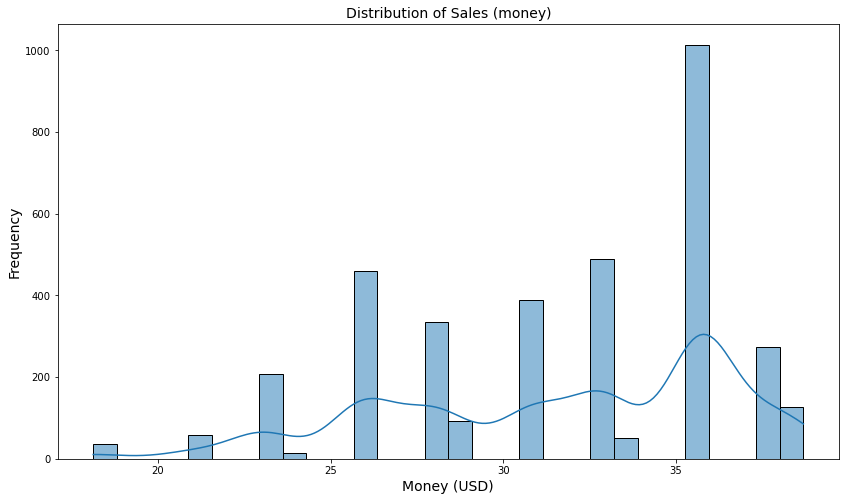

In [19]:
# A quick distribution of the 'money' column (sales amount) using histogram

plt.figure(figsize=(14, 8))
sns.histplot(coffee_data['money'], bins=30, kde=True)
plt.title('Distribution of Sales (money)', fontsize=14)
plt.xlabel('Money (USD)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)


Text(0, 0.5, 'Count')

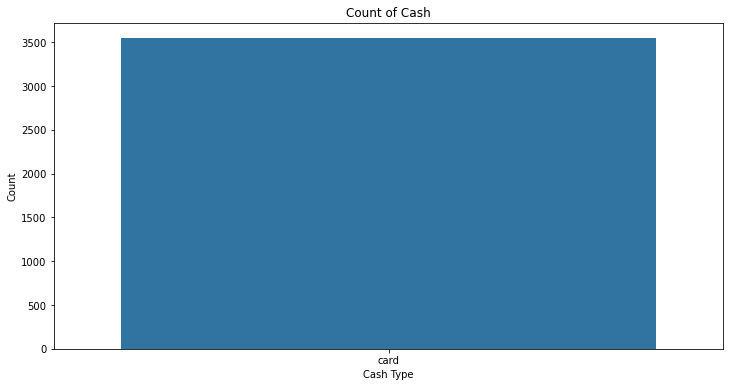

In [20]:
# Count plot for cash_type to see the usage frequency
plt.figure(figsize=(12, 6))
sns.countplot(x='cash_type', data=coffee_data)
plt.title('Count of Cash')
plt.xlabel('Cash Type')
plt.ylabel('Count')


In [21]:
# Convert the date-related information to extract more features

coffee_data.head(5)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,15:50.5
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,19:22.5
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,20:18.1
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,46:33.0
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,48:14.6


In [22]:
coffee_data['year'] = coffee_data['Date'].dt.year
coffee_data['month'] = coffee_data['Date'].dt.month

coffee_data.head(5)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,year,month
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,15:50.5,2024,3
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,19:22.5,2024,3
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,20:18.1,2024,3
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,46:33.0,2024,3
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,48:14.6,2024,3


Text(0, 0.5, 'Money')

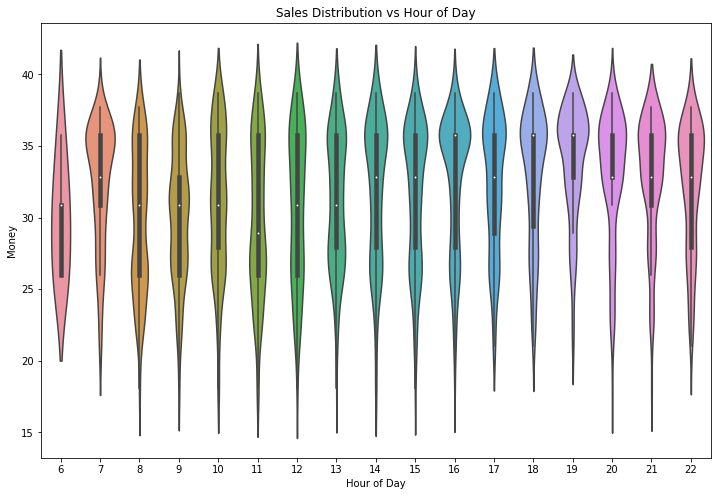

In [23]:
# Violin plot to see distribution of money based on hour_of_day

plt.figure(figsize=(12, 8))
sns.violinplot(data=coffee_data, x='hour_of_day', y='money')
plt.title('Sales Distribution vs Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Money')

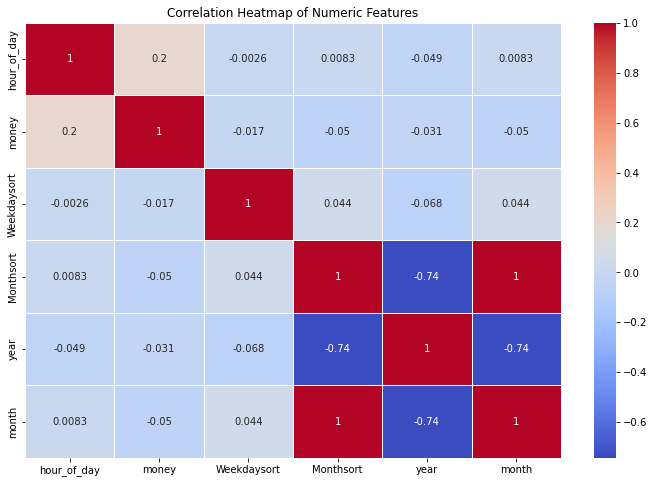

In [25]:
# If there are four or more numeric columns, draw a correlation heatmap

numeric_df = coffee_data.select_dtypes(include=[np.number])
numeric_df.head()

if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 8))
    correlation_matrix = numeric_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Heatmap of Numeric Features')

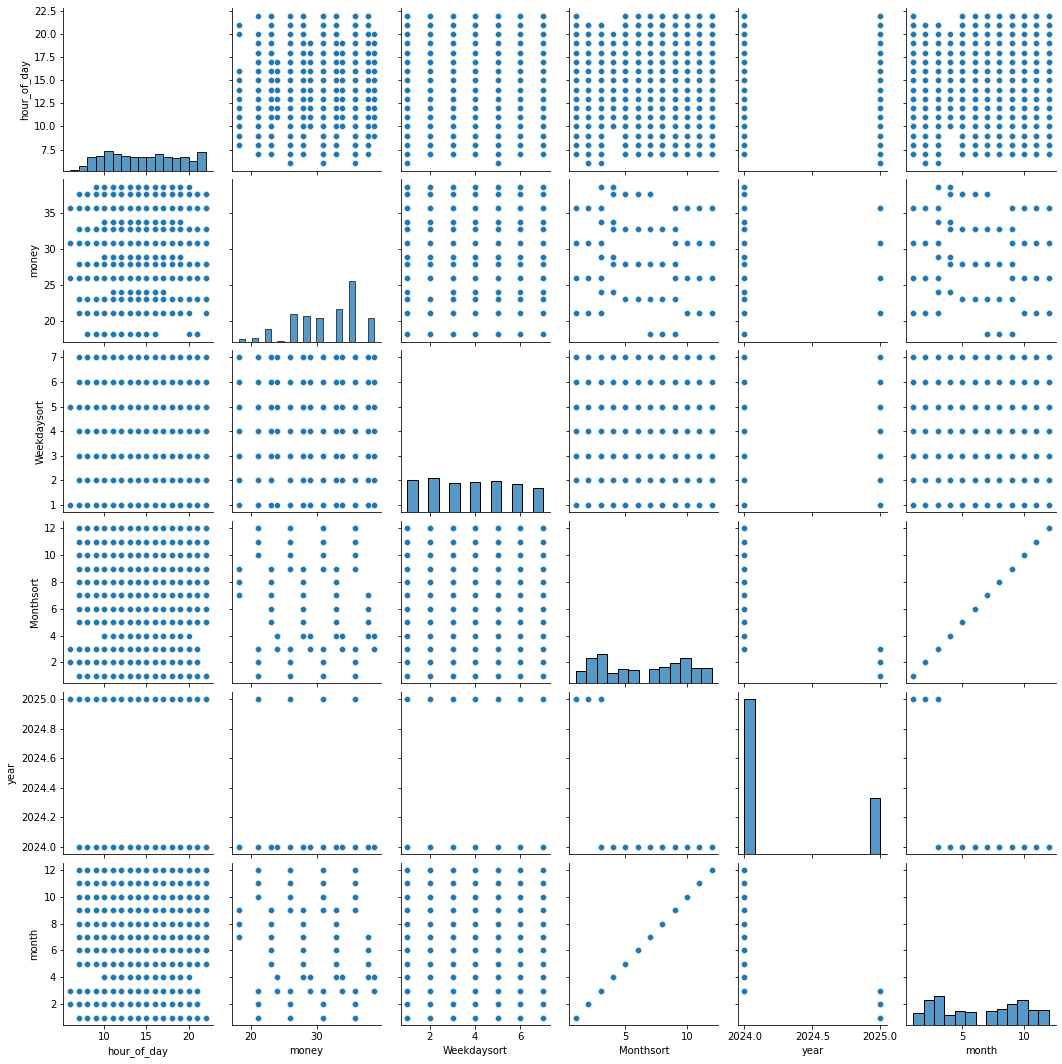

In [26]:
sns.pairplot(numeric_df)

## Sales Prediction Model

Based on the dataset, an interesting challenge is to predict the sales amount (money) based on the available features. Here, we build a regression model to predict sales. We perform the following steps:

1. Select relevant features and encode categorical features using one-hot encoding.
2. Split the data into training and test sets.
3. Train a Linear Regression model.
4. Evaluate the model using R-squared and RMSE.
5. Compute permutation importance to gauge feature contributions.

In [40]:
model_coffee_data = coffee_data.copy()  # copy the data to prepare for modeling
model_coffee_data.head(3)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,year,month
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,15:50.5,2024,3
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,19:22.5,2024,3
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,20:18.1,2024,3


R-squared: 0.977
RMSE: 0.733


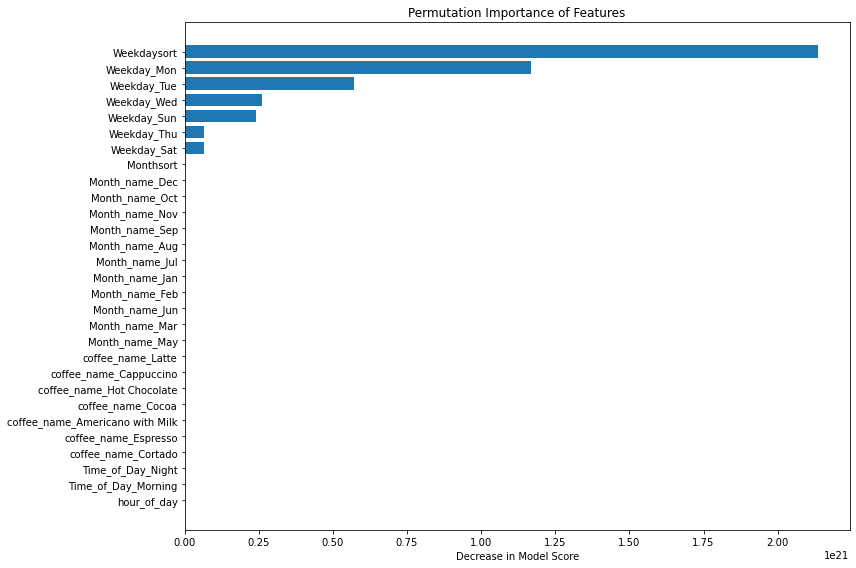

In [41]:
prediction_columns = ['hour_of_day', 'cash_type', 'coffee_name', 'Time_of_Day', 
                    'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort']

available_columns = [col for col in prediction_columns if col in model_coffee_data.columns]


# Use the one-hot to encode the data
model_coffee_data = pd.get_dummies(model_coffee_data[available_columns + ['money']], drop_first=True)

# Define the X(features) and y(target)
X = model_coffee_data.drop('money', axis=1)
y = model_coffee_data['money']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test data
y_pred = model.predict(X_test)

# Evaluate the model using R-squared and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R-squared: {r2:.3f}')
print(f'RMSE: {rmse:.3f}')

# Compute permutation importance

importances = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = importances.importances_mean.argsort()

plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_idx)), importances.importances_mean[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), X_test.columns[sorted_idx])
plt.title('Permutation Importance of Features')
plt.xlabel('Decrease in Model Score')
plt.tight_layout()
plt.show()

R-squared: 0.977
RMSE: 0.733


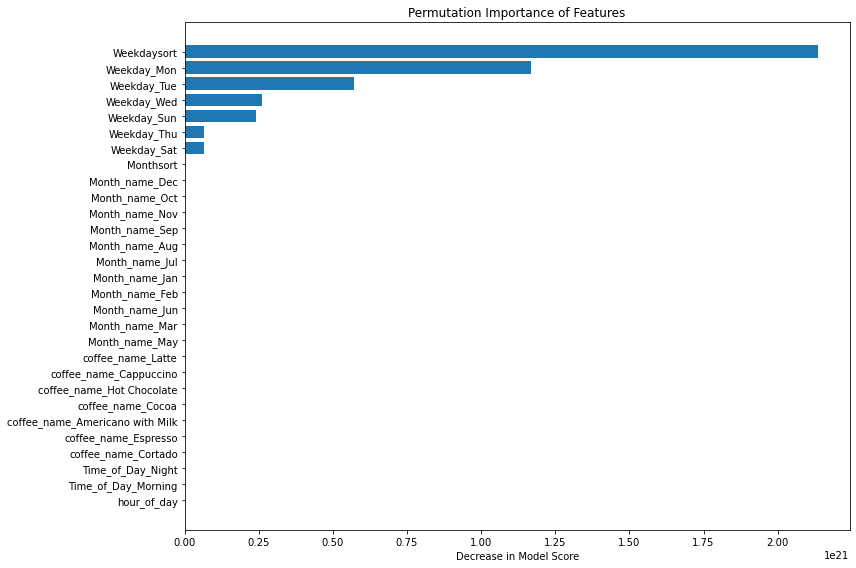

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# prediction_columns = ['hour_of_day', 'cash_type', 'coffee_name', 'Time_of_Day', 
#                       'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort']

# available_columns = [col for col in prediction_columns if col in model_coffee_data.columns]

if 'money' not in model_coffee_data.columns:
    raise KeyError("'money' column not found in model_coffee_data")

X = model_coffee_data.drop('money', axis=1)
y = model_coffee_data['money']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R-squared: {r2:.3f}')
print(f'RMSE: {rmse:.3f}')

importances = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = importances.importances_mean.argsort()

plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_idx)), importances.importances_mean[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), X_test.columns[sorted_idx])
plt.title('Permutation Importance of Features')
plt.xlabel('Decrease in Model Score')
plt.tight_layout()
plt.show()


In [49]:
new_data = pd.DataFrame({
    'hour_of_day': [10],
    'cash_type': ['card'],
    'coffee_name': ['Latte'],
    'Time_of_Day': ['Morning'],
    'Weekday': ['Fri'],
    'Month_name': ['Mar'],
    'Weekdaysort': [5],
    'Monthsort': [3]
})
new_data_encoded = pd.get_dummies(new_data, drop_first = True)
new_data_encoded = new_data_encoded.reindex(columns = X_train.columns, fill_value = 0)

predicted_price = model.predict(new_data_encoded)
print(f"Predicted Coffee Sale Price: {predicted_price[0]:.2f}")

Predicted Coffee Sale Price: 836500597.55
